# CranioVision — MC Dropout Uncertainty Visualization

**What this notebook shows:**
1. Run MC Dropout inference on a test case (5-20 stochastic forward passes)
2. Produce an **uncertainty heatmap** — per-voxel standard deviation across passes
3. Overlay uncertainty on top of segmentation so you can see WHERE the model is unsure
4. Clinical summary: confidence score + uncertain voxel flagging

**Runtime:**
- 5 samples: ~5 min on GTX 1650 4GB (demo quality)
- 20 samples: ~20 min (publication quality)

Start with `N_SAMPLES = 5` to verify it works, then increase.

## 1. Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

from src.cranovision.config import MODELS_DIR, OUTPUTS_DIR, CLASS_NAMES
from src.cranovision.data import get_splits
from src.cranovision.inference import (
    load_model,
    mc_dropout_predict,
    summarize_confidence,
    compute_region_volumes,
    make_inferer,
)

print('✅ Imports ok')

c:\Users\hrana\anaconda3\envs\ml_env_fixed\Lib\site-packages\ignite\handlers\checkpoint.py:17: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import ZeroRedundancyOptimizer


ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found.

ImportError: numpy.core._multiarray_umath failed to import

ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found.

ImportError: numpy.core._multiarray_umath failed to import

...

ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found.

ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found.

ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found.

ImportError: numpy.core._multiarray_umath failed to import

✅ Imports ok


## 2. Load model + pick a case

In [2]:
ckpt_path = MODELS_DIR / 'attention_unet_best.pth'
model = load_model('attention_unet', ckpt_path)
inferer = make_inferer()

_, _, test_cases = get_splits()
print(f'\nAvailable test cases: {len(test_cases)}')
for i, c in enumerate(test_cases[:8]):
    print(f'  {i}: {c["case_id"]}')

Loading attention_unet from attention_unet_best.pth...
  ✓ Loaded. Device: cuda
Scanning 200 patient folders in BraTS2024_small_dataset/
  Valid cases: 200
Loading existing split from data_split.json
  Train: 140 (70%) | Val: 30 (15%) | Test: 30 (15%)

Available test cases: 30
  0: BraTS-GLI-02196-105
  1: BraTS-GLI-02103-106
  2: BraTS-GLI-02194-106
  3: BraTS-GLI-02608-105
  4: BraTS-GLI-02247-102
  5: BraTS-GLI-02103-100
  6: BraTS-GLI-02216-103
  7: BraTS-GLI-02632-102


In [3]:
# Pick a case — try index 4 (BraTS-GLI-02247) which had a hard Enhancing class
# or index 0 (BraTS-GLI-02196-105) which is well-segmented
CASE_IDX    = 0
N_SAMPLES   = 5   # start small; increase to 20 for better uncertainty

case = test_cases[CASE_IDX]
print(f'Target case : {case["case_id"]}')
print(f'N samples   : {N_SAMPLES}')

Target case : BraTS-GLI-02196-105
N samples   : 5


## 3. Run MC Dropout inference

**⏰ This takes a few minutes.** Coffee break time.

In [4]:
result = mc_dropout_predict(
    model=model,
    case_dict=case,
    n_samples=N_SAMPLES,
    inferer=inferer,
    verbose=True,
)

print(f'\n✓ Inference complete')

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


MC Dropout active — 18 dropout layers enabled
Running 5 stochastic forward passes...


`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


  Sample  1/5
  Sample  2/5
  Sample  3/5
  Sample  4/5
  Sample  5/5

✓ Inference complete


## 4. Clinical summary

In [5]:
summary  = summarize_confidence(result, uncertain_threshold=0.15)
volumes  = compute_region_volumes(result['pred'])

print('=' * 60)
print(f'CLINICAL REPORT — {result["case_id"]}')
print('=' * 60)
print(f'Model               : Attention U-Net')
print(f'MC Dropout samples  : {result["n_samples"]}')
print()
print(f'Tumor volumes (cm³):')
for name in CLASS_NAMES[1:]:
    print(f'  {name:20s}: {volumes[name]:>7.2f} cm³')
print(f'  {"Total tumor":20s}: {volumes["Total tumor"]:>7.2f} cm³')
print()
print(f'Confidence assessment:')
print(f'  Overall mean       : {summary["mean_confidence"]:.4f}')
print(f'  Uncertain voxels   : {summary["uncertain_voxel_count"]:,}')
print(f'  Uncertain fraction : {summary["uncertain_fraction"]*100:.2f}% of tumor')
print()
print(f'Per-class confidence:')
for name, stats in summary['per_class'].items():
    flag = ' ⚠ REVIEW' if stats['mean_confidence'] < 0.85 else ''
    print(f'  {name:20s}: {stats["mean_confidence"]:.4f}{flag}')
print('=' * 60)

if summary['mean_confidence'] >= 0.90:
    print('✓ HIGH CONFIDENCE — model is reliable for this case')
elif summary['mean_confidence'] >= 0.75:
    print('~ MODERATE CONFIDENCE — recommend quick radiologist review')
else:
    print('⚠ LOW CONFIDENCE — mandatory radiologist review')

CLINICAL REPORT — BraTS-GLI-02196-105
Model               : Attention U-Net
MC Dropout samples  : 5

Tumor volumes (cm³):
  Edema               :  113.14 cm³
  Enhancing tumor     :   51.71 cm³
  Necrotic core       :    9.55 cm³
  Total tumor         :  174.40 cm³

Confidence assessment:
  Overall mean       : 0.9763
  Uncertain voxels   : 252
  Uncertain fraction : 0.14% of tumor

Per-class confidence:
  Edema               : 0.9792
  Enhancing tumor     : 0.9719
  Necrotic core       : 0.9648
✓ HIGH CONFIDENCE — model is reliable for this case


## 5. Pick the most interesting slice

Find the slice with the most uncertainty — that's what's worth looking at.

In [6]:
unc = result['uncertainty'].numpy()
pred = result['pred'].numpy()

# Score each axial slice by total uncertainty within predicted tumor
unc_per_slice = np.array([
    unc[:, :, z][pred[:, :, z] > 0].sum() if (pred[:, :, z] > 0).any() else 0.0
    for z in range(unc.shape[2])
])
z_hot = int(unc_per_slice.argmax())

# Also find biggest-tumor-area slice for comparison
tumor_per_slice = (pred > 0).sum(axis=(0, 1))
z_big = int(tumor_per_slice.argmax())

print(f'Slice with most uncertainty  : z = {z_hot}  (sum unc = {unc_per_slice[z_hot]:.1f})')
print(f'Slice with largest tumor     : z = {z_big}  (voxels = {tumor_per_slice[z_big]})')

# We'll visualize the uncertainty-hot slice
TARGET_SLICE = z_hot
print(f'\nVisualizing slice z = {TARGET_SLICE}')

Slice with most uncertainty  : z = 105  (sum unc = 114.8)
Slice with largest tumor     : z = 110  (voxels = 4288)

Visualizing slice z = 105


## 6. The main visualization — 4 panels

| Panel | What you see |
|---|---|
| 1 | T1c input MRI |
| 2 | Model's segmentation (deterministic mean) |
| 3 | Uncertainty heatmap — brighter = less confident |
| 4 | Segmentation + uncertainty overlay (THE clinical view) |

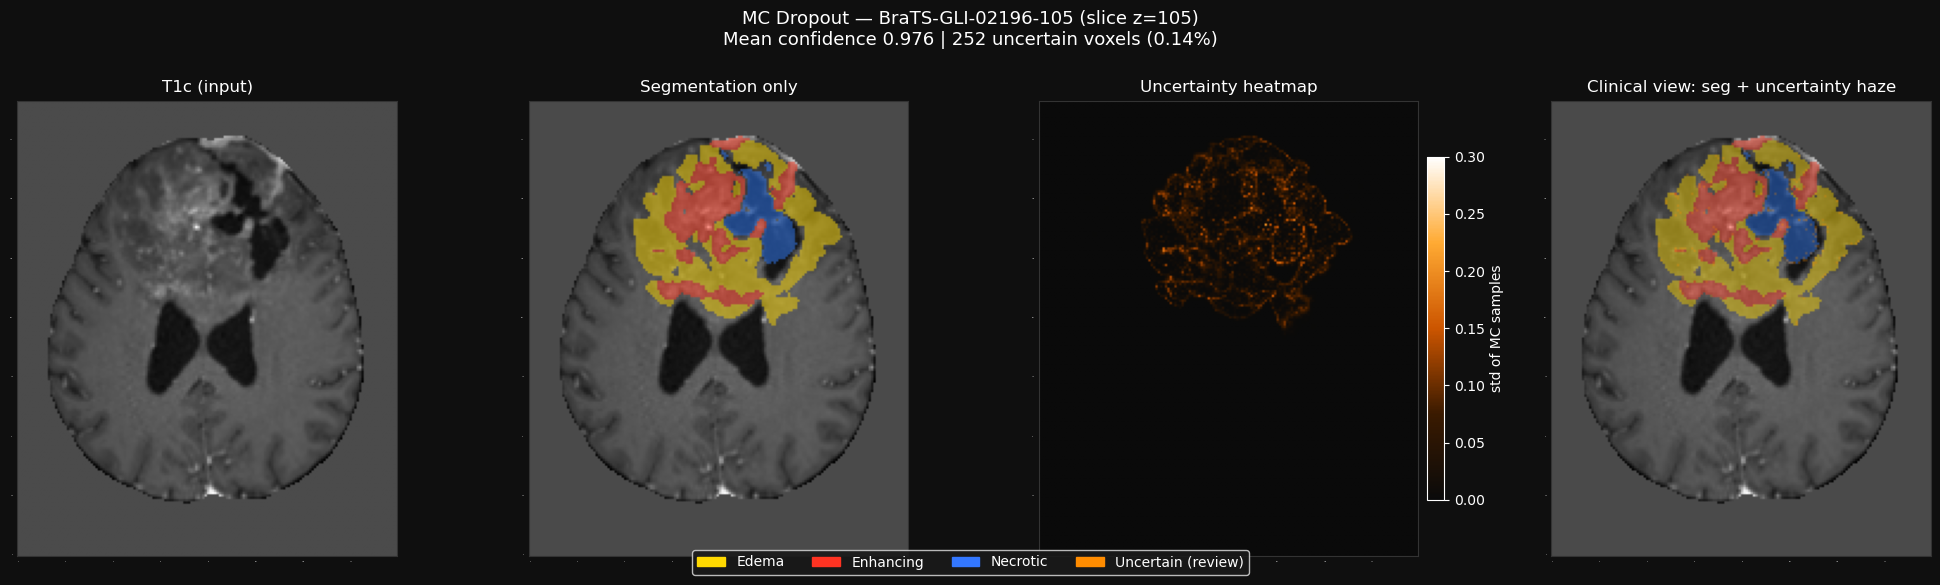

Saved: D:\2_ML PROJECTS\30. Brainstorm\CranioVision\outputs\mc_dropout_BraTS-GLI-02196-105.png


In [7]:
# Custom colormap for uncertainty — black → orange → white
unc_cmap = LinearSegmentedColormap.from_list(
    'uncertainty',
    ['#0a0a0a', '#3a1a00', '#cc5500', '#ffaa33', '#ffffff']
)

def overlay_seg_with_unc(mri, seg, unc, unc_threshold=0.1):
    """MRI + segmentation colors + uncertainty haze where unc > threshold."""
    mri_norm = (mri - mri.min()) / (mri.max() - mri.min() + 1e-8)
    rgb = np.stack([mri_norm, mri_norm, mri_norm], axis=-1)

    seg_colors = {
        1: np.array([1.0, 0.85, 0.0]),   # edema
        2: np.array([1.0, 0.2,  0.1]),   # enhancing
        3: np.array([0.2, 0.5,  1.0]),   # necrotic
    }
    for lbl, color in seg_colors.items():
        mask = seg == lbl
        if mask.any():
            rgb[mask] = 0.55 * rgb[mask] + 0.45 * color

    # Uncertainty haze — orange/white blend based on magnitude
    unc_clip = np.clip(unc, 0, 0.3) / 0.3      # normalize to 0..1
    haze_mask = unc > unc_threshold
    haze_strength = unc_clip[haze_mask]
    orange = np.array([1.0, 0.55, 0.0])
    for idx, s in zip(np.argwhere(haze_mask), haze_strength):
        y, x = idx
        rgb[y, x] = (1 - s * 0.7) * rgb[y, x] + s * 0.7 * orange

    return np.clip(rgb, 0, 1)


# Extract slice data
img_slice = result['image'][1, :, :, TARGET_SLICE].numpy().T    # T1c, channel 1
seg_slice = pred[:, :, TARGET_SLICE].T
unc_slice = unc[:, :, TARGET_SLICE].T

fig, axes = plt.subplots(1, 4, figsize=(20, 5.5))
fig.patch.set_facecolor('#0f0f0f')

img_norm = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min() + 1e-8)

axes[0].imshow(img_norm, cmap='gray', origin='lower')
axes[0].set_title('T1c (input)', color='white', fontsize=12)

# Seg only (no uncertainty yet)
def overlay_seg_only(mri, seg):
    mri_n = (mri - mri.min()) / (mri.max() - mri.min() + 1e-8)
    rgb = np.stack([mri_n, mri_n, mri_n], axis=-1)
    cmap = {1: [1.0, 0.85, 0], 2: [1.0, 0.2, 0.1], 3: [0.2, 0.5, 1.0]}
    for lbl, color in cmap.items():
        m = seg == lbl
        if m.any():
            rgb[m] = 0.5 * rgb[m] + 0.5 * np.array(color)
    return np.clip(rgb, 0, 1)

axes[1].imshow(overlay_seg_only(img_slice, seg_slice), origin='lower')
axes[1].set_title('Segmentation only', color='white', fontsize=12)

# Pure uncertainty
im = axes[2].imshow(unc_slice, cmap=unc_cmap, origin='lower', vmin=0, vmax=0.3)
axes[2].set_title('Uncertainty heatmap', color='white', fontsize=12)
cbar = plt.colorbar(im, ax=axes[2], fraction=0.04, pad=0.02)
cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white')
cbar.outline.set_edgecolor('white')
cbar.set_label('std of MC samples', color='white')

# Combined — THE clinical view
axes[3].imshow(overlay_seg_with_unc(img_slice, seg_slice, unc_slice), origin='lower')
axes[3].set_title('Clinical view: seg + uncertainty haze', color='white', fontsize=12)

for ax in axes:
    ax.set_facecolor('#0f0f0f')
    ax.tick_params(colors='white', labelsize=0, length=0)
    for s in ax.spines.values():
        s.set_edgecolor('#333')

legend_patches = [
    mpatches.Patch(color='#FFD900', label='Edema'),
    mpatches.Patch(color='#FF3322', label='Enhancing'),
    mpatches.Patch(color='#3377FF', label='Necrotic'),
    mpatches.Patch(color='#ff8c00', label='Uncertain (review)'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4,
           facecolor='#1a1a1a', labelcolor='white', fontsize=10,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

plt.suptitle(
    f'MC Dropout — {result["case_id"]} (slice z={TARGET_SLICE})\n'
    f'Mean confidence {summary["mean_confidence"]:.3f} | '
    f'{summary["uncertain_voxel_count"]:,} uncertain voxels '
    f'({summary["uncertain_fraction"]*100:.2f}%)',
    color='white', fontsize=13, y=1.02)

plt.tight_layout()
save_path = OUTPUTS_DIR / f'mc_dropout_{result["case_id"]}.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(f'Saved: {save_path}')

## 7. Which voxels are most uncertain?

Histogram of per-voxel uncertainty across the whole tumor — shows the *distribution* of confidence.

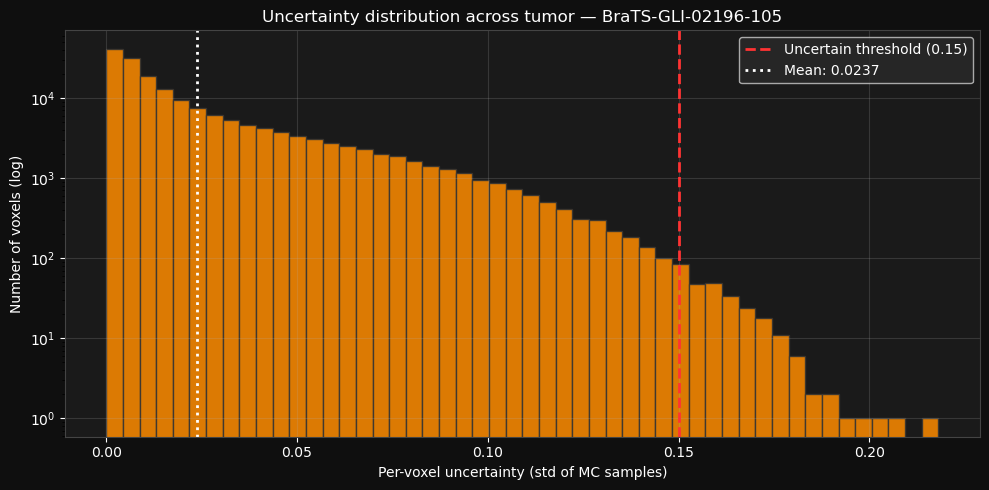


Distribution of uncertainty:
  Total tumor voxels : 174,402
  Mean uncertainty   : 0.0237
  Median             : 0.0119
  95th percentile    : 0.0850
  Max                : 0.2181


In [8]:
tumor_mask = pred > 0
unc_values = unc[tumor_mask]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a1a')

ax.hist(unc_values, bins=50, color='#ff8c00', edgecolor='#333', alpha=0.85)
ax.axvline(x=0.15, color='#ff3333', linestyle='--', linewidth=2,
           label=f'Uncertain threshold (0.15)')
ax.axvline(x=unc_values.mean(), color='#ffffff', linestyle=':',
           linewidth=2, label=f'Mean: {unc_values.mean():.4f}')

ax.set_xlabel('Per-voxel uncertainty (std of MC samples)', color='white')
ax.set_ylabel('Number of voxels (log)', color='white')
ax.set_yscale('log')
ax.set_title(f'Uncertainty distribution across tumor — {result["case_id"]}',
              color='white', fontsize=12)
ax.tick_params(colors='white')
ax.legend(facecolor='#2a2a2a', labelcolor='white')
ax.grid(alpha=0.2)
for s in ax.spines.values():
    s.set_edgecolor('#444')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / f'mc_dropout_hist_{result["case_id"]}.png',
             dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

print(f'\nDistribution of uncertainty:')
print(f'  Total tumor voxels : {tumor_mask.sum():,}')
print(f'  Mean uncertainty   : {unc_values.mean():.4f}')
print(f'  Median             : {np.median(unc_values):.4f}')
print(f'  95th percentile    : {np.percentile(unc_values, 95):.4f}')
print(f'  Max                : {unc_values.max():.4f}')

## 8. Try a harder case — where confidence drops

From earlier test results, case 11 (BraTS-GLI-02105-102) had only 0.29 Dice — the model struggled. Let's see what MC Dropout says about it.

In [9]:
# Run this cell only if you want to analyze a hard case (takes ~5 more min)
RUN_HARD_CASE = False   # set to True to run

if RUN_HARD_CASE:
    hard_case = test_cases[11]   # BraTS-GLI-02105-102 — known to be hard
    print(f'Hard case: {hard_case["case_id"]}\nRunning {N_SAMPLES} MC samples...\n')

    hard_result = mc_dropout_predict(
        model=model, case_dict=hard_case,
        n_samples=N_SAMPLES, inferer=inferer, verbose=True,
    )
    hard_summary = summarize_confidence(hard_result)

    print('\n' + '=' * 60)
    print(f'Hard case confidence comparison:')
    print('=' * 60)
    print(f'Easy case  ({result["case_id"]:28s}): confidence {summary["mean_confidence"]:.4f}')
    print(f'Hard case  ({hard_result["case_id"]:28s}): confidence {hard_summary["mean_confidence"]:.4f}')
    print()
    print(f'→ Lower confidence on hard cases = MC Dropout detects the failure automatically!')
else:
    print('Skipped — set RUN_HARD_CASE = True to try')

Skipped — set RUN_HARD_CASE = True to try
